## Calculating the energy consumption of the English Housing Stock using CUBES with data from Tabula and Hotmaps

### Importing modules

In [3]:
from cubes.construct import building
from cubes.construct import sample
from cubes.construct.extractor import Extractor
from cubes.construct import constants
from cubes.construct.building import Building
from cubes.package.simple_simulation import prepare_simulation
from cubes.package import envconfig
from geomeppy import IDF
import pandas as pd
import matplotlib.pyplot as plt

import os
from pathlib import Path

### Defining methods

In [2]:
def test_specific_idf(building_code):
    geometry_data = constants.raw_geometry_data[constants.raw_geometry_data['REFERENCE BUILDING CODE'] == building_code]
    systems_data =constants.clean_system_data[constants.clean_system_data['Building typology'] == building_code]
    #print(geometry_data.head())
    #for c in geometry_data.columns:
    #    print(c)
    #print(systems_data.columns)

    #return
    geometry_data = geometry_data.reset_index(drop = True)
    extracted = Extractor(geometry_data, systems_data)

    BC = extracted.create_building_config_object()
    EC = envconfig.EnvConfig(observe_zone_temperature=True,observe_electricity_demand=True,observe_fuel_demand=True,observe_outside_temperature=True)    
    building=Building(BC)
    building.build()
    idf = building.get_idf()

    cwd_path = os.getcwd()
    env_data_path = os.path.join(os.path.join(cwd_path,"cases"), str(building_code))
    print(env_data_path)
    output_directory_path = os.path.join(env_data_path, "output")

    Path(env_data_path).mkdir(parents=True, exist_ok=True)
    Path(output_directory_path).mkdir(parents=True, exist_ok=True)

    idf,weather_file=prepare_simulation(idf,BC,EC)
    
    idf.save(filename=env_data_path + "/building.idf")
    print(weather_file)
    idf.run(
        expandobjects=True,
        readvars=True,
        weather=weather_file,
        output_directory=output_directory_path,
)

    #get results
    results = pd.read_csv(output_directory_path+"/eplusout.csv")
    electricity = results["Whole Building:Facility Total Building Electricity Demand Rate [W](Hourly)"].sum()
    gas = results["MAIN BOILER:Boiler NaturalGas Rate [W](Hourly)"].sum()
    return {"gas":gas, "electricity":electricity, "floor_area":building.get_floor_area()}

def run_archetypes(codes):
    data = {'Code': [], 'Gas [Wh]': [], 'Electricity [Wh]': [], 'Floor Area [m2]':[]}

    #counter = 0
    for code in codes:
        results = test_specific_idf(code)
        
        #ht = pd.read_html("/workspaces/CUBES/exp/jack/EHS-energy-comparison/input_case_1/output/eplustbl.htm")[0]
        #energy = ht.iloc[1,1]
        data['Code'].append(code)
        data['Gas [Wh]'].append(results["gas"])
        data['Electricity [Wh]'].append(results["electricity"])
        data['Floor Area [m2]'].append(results["floor_area"])

        #break

    df = pd.DataFrame(data)

    return df


#def run_archetypes(codes):
#    data = {'Code': [], 'Energy / GJ': []}
#
#    for code in codes:
#        test_specific_idf(code)
#        ht = pd.read_html("/workspaces/CUBES/exp/jack/EHS-energy-comparison/input_case_1/output/eplustbl.htm")[0]
#        energy = ht.iloc[1,1]
#        data['Code'].append(code)
#        data['Energy / GJ'].append(energy)
#
#    df = pd.DataFrame(data)
#
#    return df

#### Getting the number of English buildings from episcope

In [298]:
episcope = pd.read_html('https://episcope.eu/building-typology/country/gb/')

epi_num_buildings = episcope[15]
epi_num_buildings = epi_num_buildings.fillna('')
epi_num_buildings.columns = epi_num_buildings.iloc[0]
epi_num_buildings= epi_num_buildings.drop(epi_num_buildings.index[0])

rows_to_drop = epi_num_buildings[epi_num_buildings.isin(['*']).any(axis=1)].index
epi_num_buildings = epi_num_buildings.drop(labels=rows_to_drop, axis=0)

epi_num_buildings[epi_num_buildings.columns[1:]] = epi_num_buildings[epi_num_buildings.columns[1:]].apply(pd.to_numeric, errors='coerce')
epi_num_buildings = epi_num_buildings.dropna(axis=0)

def convert_html_data(html_data, building_type):
    dataset = html_data[html_data.iloc[:,0].str.contains(building_type)]

    if 'Apartment' not in building_type:
        dataset.iloc[-1, 1:] = dataset.iloc[-1,1:]/2

        data = {dataset.columns[0]: [building_type+' post 2010'], 
                dataset.columns[1]: [dataset.iloc[-1,1]],
                dataset.columns[2]: [dataset.iloc[-1,2]],
                dataset.columns[3]: [dataset.iloc[-1,3]]}

        df1 = pd.DataFrame(data)
        
        dataset = pd.concat([dataset, df1])

    return dataset

building_type = ['Apartment','MFH', 'SFH', 'Terraced']
master_df = pd.DataFrame()

for b_t in building_type:
    temp_df = convert_html_data(epi_num_buildings, b_t)

    master_df = pd.concat([master_df, temp_df])

master_df = master_df.reset_index(drop=True)
master_df['estimated number of buildings (thousands)**'] = master_df['estimated number of buildings (thousands)**']*1000
master_df['number of dwellings (thousands)'] = master_df['number of dwellings (thousands)']*1000

num_buildings = master_df['estimated number of buildings (thousands)**']


#### Getting the English Archetype codes

In [296]:
gb_ambience = pd.read_csv('/workspaces/CUBES/src/cubes/data/housing_stock/gb_Geometry_Construction.csv')
gb_codes = gb_ambience.iloc[:,1]

### Running the simulations on the English Housing Stock
The annual energy consumption and code is stored within a dataframe, df

In [ ]:
df = run_archetypes(gb_codes)

#### Adding information to the dataframe
Information like the number of buildings, total energy consumption and tabula's estimate

In [42]:
df = pd.concat([df, num_buildings], axis=1)
df['Gas [Wh]'] = pd.to_numeric(df['Gas [Wh]'])
df['Electricity [Wh]'] = pd.to_numeric(df['Electricity [Wh]'])

In [283]:
tabula = {'Floor_Area / m2':[3362, 4357, 4045, 425, 481, 447, 559, 633, 693, 994, 994,
                             198, 153, 134, 123, 127, 141, 149, 149, 105, 93, 88, 85, 
                             74, 80, 98, 98], 
                             
        'Primary_Energy / kWh/m2' :[387.8, 307.9, 78.3, 423.5, 441.1, 437.8, 375.7, 
                                    318.7, 306.9, 89.8, 84.6, 228.3, 233.5, 231.7, 
                                    221.6, 194.6, 180.0, 97.6, 92.9, 238.5, 246.5, 
                                    238.6, 218.9, 205.9, 198.6, 99.4, 94.1]}

tabula_df = pd.DataFrame(tabula)

In [284]:
tabula_df['Total Energy / kWh'] = (tabula_df['Floor_Area / m2']*tabula_df['Primary_Energy / kWh/m2'])
tabula_df['num_buildings'] = df['BUILDING STOCK SEGMENT NUMBER OF BUILDINGS']
tabula_df['TABULA / TWh'] = (tabula_df['Total Energy / kWh']*tabula_df['num_buildings'])/10**9

In [92]:
df['CUBES / Wh'] = (df['Gas [Wh]'] + df['Electricity [Wh]'])*df['BUILDING STOCK SEGMENT NUMBER OF BUILDINGS']
df['CUBES / TWh'] = (df['CUBES / Wh'])/10**12
df['TABULA / TWh'] = tabula_df['TABULA / TWh']
df['cumsum_Tabula'] = df['TABULA / TWh'].cumsum()
df['cumsum_CUBES'] = df['CUBES / TWh'].cumsum()


In [94]:
cwd_path = os.getcwd()
output_directory_path = os.path.join(cwd_path, "results")
df.to_csv('/workspaces/CUBES/exp/jack/EHS-energy-comparison/output/cubes_tabula_comparison.csv')

#### Importing previously determined results

In [4]:
df = pd.read_csv('/workspaces/CUBES/exp/jack/EHS-energy-comparison/output/results.csv', index_col=0)

In [5]:
code_types = ['AB', 'MFH', 'SFH', 'TH']

df10 = pd.DataFrame()

for c_t in code_types:
    dataset = df[df.iloc[:,0].str.contains(c_t)]

    cubes_energy_demand = dataset['CUBES / TWh'].sum()
    tabula_energy_demand = dataset['TABULA / TWh'].sum()

    data = {'Residential_Type' :[c_t],
            'CUBES_Estimate_TWh': [cubes_energy_demand],
            'TABULA_Estimate_TWh': [tabula_energy_demand]}
    
    df11 = pd.DataFrame(data=data)

    df10 = pd.concat([df10,df11])

    

In [46]:
df14 = pd.read_csv('output/condensed_results.csv', index_col=0)

In [62]:
df

,Code,Gas [Wh],Electricity [Wh],Floor Area [m2],estimated number of buildings (thousands)**,CUBES / Wh,CUBES / TWh,TABULA / TWh,cumsum_Tabula,cumsum_CUBES
0,GB-AB-03,1.970949e+08,9.491753e+07,3481.50,2000.0,5.840249e+11,0.584025,2.607567,2.607567,0.584025
1,GB-AB-04,1.199785e+08,1.276388e+08,4681.69,4000.0,9.904693e+11,0.990469,5.366081,7.973648,1.574494
2,GB-AB-07,5.109637e+07,1.130815e+08,4147.74,1000.0,1.641779e+11,0.164178,0.316723,8.290372,1.738672
3,GB-MFH-01,3.466966e+07,1.219574e+07,447.33,373000.0,1.748079e+13,17.480791,67.135338,75.425709,19.219463
4,GB-MFH-02,3.724760e+07,1.375548e+07,504.54,108000.0,5.508333e+12,5.508333,22.914263,98.339972,24.727796
5,GB-MFH-03,2.253798e+07,1.281325e+07,469.98,168000.0,5.939007e+12,5.939007,32.877029,131.217001,30.666803
6,GB-MFH-04,2.271284e+07,1.594909e+07,585.00,222000.0,8.582947e+12,8.582947,46.623619,177.840620,39.249750
7,GB-MFH-05,2.263479e+07,1.800284e+07,660.33,106000.0,4.307589e+12,4.307589,21.384133,199.224752,43.557340
8,GB-MFH-06,1.976806e+07,1.965664e+07,720.99,73000.0,2.878003e+12,2.878003,15.525764,214.750516,46.435342
9,GB-MFH-07,1.872549e+07,2.803850e+07,1028.43,24000.0,1.122336e+12,1.122336,2.142269,216.892785,47.557678


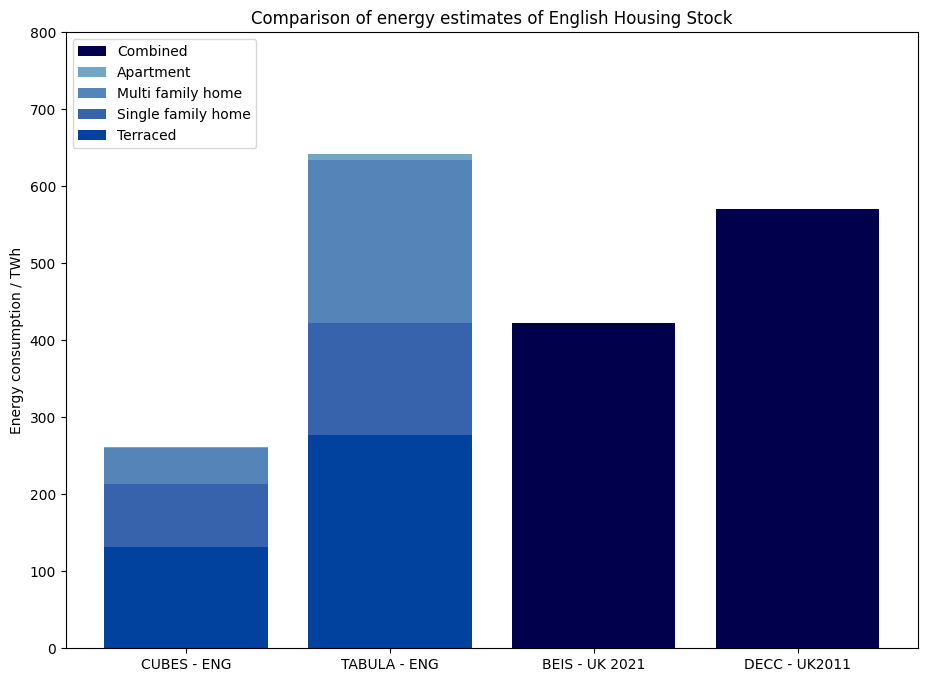

In [61]:
fig = plt.figure(figsize=(11,8))
ax = fig.add_subplot()
x = ['CUBES - ENG', 'TABULA - ENG', 'BEIS - UK 2021', 'DECC - UK2011']
y4= df14.iloc[0,1:]
y3 = df14.iloc[1,1:]
y2 = df14.iloc[2,1:]
y1 = df14.iloc[3,1:]
y5 = df14.iloc[4,1:]
#00429d,#3762ac,#5584b9,#71a7c5,#abc6ba

ax.bar(x, y1, color='#00429d', label='Terraced')
ax.bar(x, y2, bottom=y1, color='#3762ac', label='Single family home')
ax.bar(x, y3, bottom=y2+y1, color='#5584b9', label='Multi family home')
ax.bar(x, y4, bottom=y3+y2+y1, color='#71a7c5', label='Apartment')
ax.bar(x, y5, bottom=y4+y3+y2+y1, color='#00004d', label='Combined')

plt.ylim([0,800])

ax.set_title('Comparison of energy estimates of English Housing Stock')
plt.ylabel('Energy consumption / TWh')

#invert legend
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles[::-1], labels[::-1], loc='upper left')


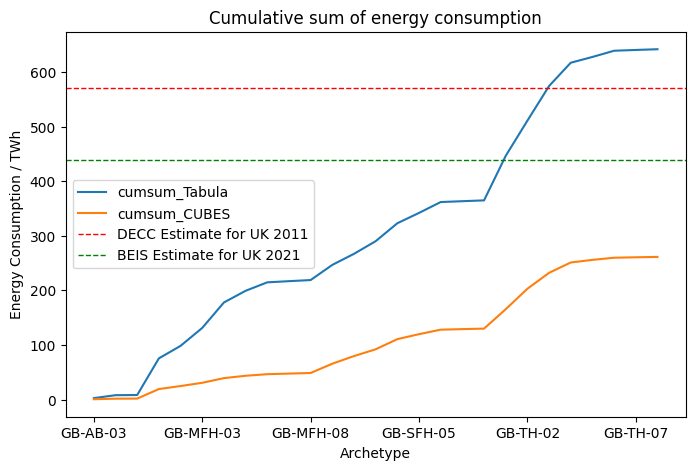

In [300]:
plot = df.plot.line(x='Code', y=['cumsum_Tabula', 'cumsum_CUBES'], figsize=(8,5))
plot.axhline(y=571, color= 'red', linewidth=1, linestyle='--', label="DECC Estimate for UK 2011")
plot.axhline(y=438, color= 'green', linewidth=1, linestyle='--', label="BEIS Estimate for UK 2021")
plot.set_title('Cumulative sum of energy consumption')

plot.set_ylabel('Energy Consumption / TWh')
plot.set_xlabel('Archetype')
plot.legend()



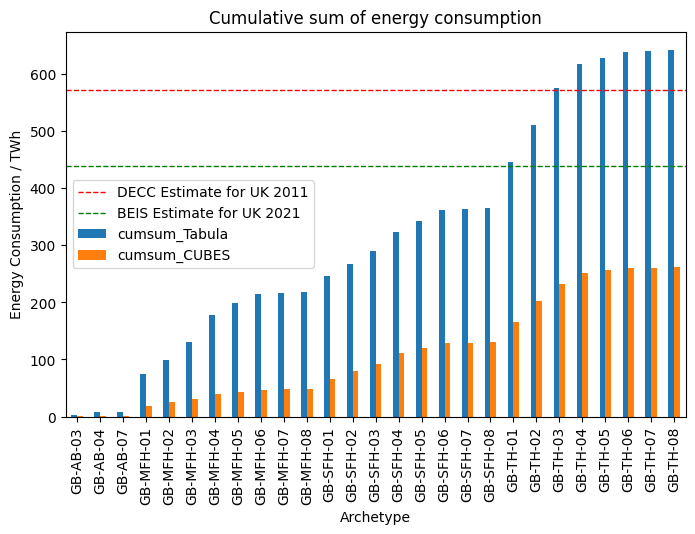

In [301]:
plot = df.plot.bar(x='Code', y=['cumsum_Tabula', 'cumsum_CUBES'], figsize=(8,5))
plot.axhline(y=571, color= 'red', linewidth=1, linestyle='--', label="DECC Estimate for UK 2011")
plot.axhline(y=438, color= 'green', linewidth=1, linestyle='--', label="BEIS Estimate for UK 2021")
plot.set_title('Cumulative sum of energy consumption')

plot.set_ylabel('Energy Consumption / TWh')
plot.set_xlabel('Archetype')
plot.legend()



Text(0.5, 1.0, 'Comparison between CUBES and Tabula archetype energy consumption')

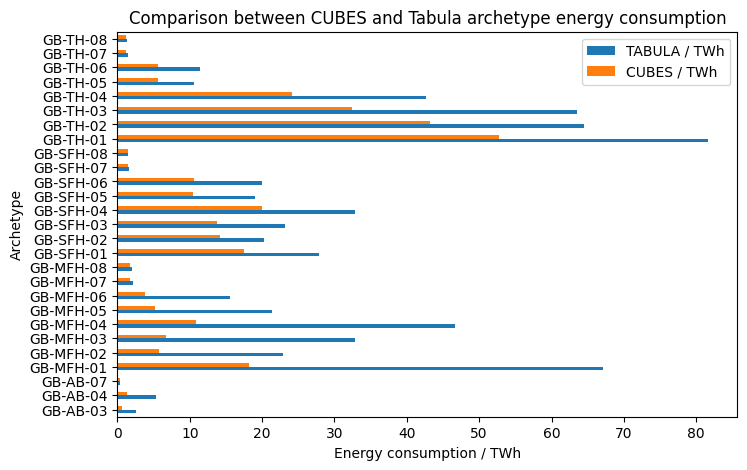

In [295]:
sp = df.plot.barh(x='Code', y=['TABULA / TWh', 'CUBES / TWh'], figsize=(8,5))
sp.set_xlabel('Energy consumption / TWh')
sp.set_ylabel('Archetype')
sp.set_title('Comparison between CUBES and Tabula archetype energy consumption')

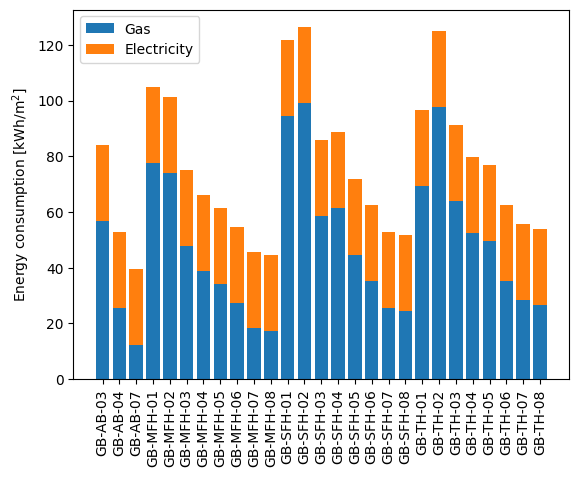

In [7]:
import matplotlib.pyplot as plt

fig,ax = plt.subplots()
ax.bar(df["Code"],df["Gas [Wh]"]/df["Floor Area [m2]"]/1000,label="Gas")
ax.bar(df["Code"],df["Electricity [Wh]"]/df["Floor Area [m2]"]/1000,bottom=df["Gas [Wh]"]/df["Floor Area [m2]"]/1000,label='Electricity')
ax.set_ylabel("Energy consumption [$\mathregular{kWh/m}^2$]")
plt.xticks(rotation='vertical')
ax.legend()

([0,
  1,
  2,
  3,
  4,
  5,
  6,
  7,
  8,
  9,
  10,
  11,
  12,
  13,
  14,
  15,
  16,
  17,
  18,
  19,
  20,
  21,
  22,
  23,
  24,
  25,
  26],
 [Text(0, 0, 'GB-AB-03'),
  Text(1, 0, 'GB-AB-04'),
  Text(2, 0, 'GB-AB-07'),
  Text(3, 0, 'GB-MFH-01'),
  Text(4, 0, 'GB-MFH-02'),
  Text(5, 0, 'GB-MFH-03'),
  Text(6, 0, 'GB-MFH-04'),
  Text(7, 0, 'GB-MFH-05'),
  Text(8, 0, 'GB-MFH-06'),
  Text(9, 0, 'GB-MFH-07'),
  Text(10, 0, 'GB-MFH-08'),
  Text(11, 0, 'GB-SFH-01'),
  Text(12, 0, 'GB-SFH-02'),
  Text(13, 0, 'GB-SFH-03'),
  Text(14, 0, 'GB-SFH-04'),
  Text(15, 0, 'GB-SFH-05'),
  Text(16, 0, 'GB-SFH-06'),
  Text(17, 0, 'GB-SFH-07'),
  Text(18, 0, 'GB-SFH-08'),
  Text(19, 0, 'GB-TH-01'),
  Text(20, 0, 'GB-TH-02'),
  Text(21, 0, 'GB-TH-03'),
  Text(22, 0, 'GB-TH-04'),
  Text(23, 0, 'GB-TH-05'),
  Text(24, 0, 'GB-TH-06'),
  Text(25, 0, 'GB-TH-07'),
  Text(26, 0, 'GB-TH-08')])

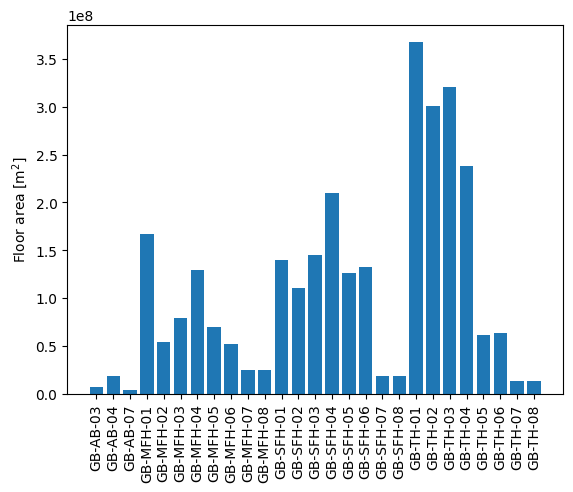

In [63]:
fig,ax = plt.subplots()
ax.bar(df["Code"],df["estimated number of buildings (thousands)**"]*df["Floor Area [m2]"])
ax.set_ylabel("Floor area [$\mathregular{m}^2$]")
plt.xticks(rotation='vertical')
